# Relevant Papers
>Serrano-Gotarredona, T., Linares-Barranco, B., & Andreou, A. G. (1998).  
>Adaptive Resonance Theory Microchips: Circuit Design Techniques.  
>Norwell, MA, USA: Kluwer Academic Publishers.  

# Import Necessary Libraries

In [1]:
import numpy as np
from sklearn.datasets import load_iris, make_blobs
import matplotlib.pyplot as plt

from artlib import FuzzyART, SimpleARTMAP

# Dataset Generation
In this example we use fuzzy art as the basis for SimpleARTMAP

For this we use `sklearn` to generate a dataset consisting of 150 input vectors, each of length 2, with 3 centers.

In [2]:
data, target = make_blobs(n_samples=150, centers=3, cluster_std=0.50, random_state=0, shuffle=False)
print("Data has shape:", data.shape)

Data has shape: (150, 2)


## Clustering with ArtMap

In the example below, we initialize the inital fuzzy ART model with the following parameters  

- `rho`: The vigilance parameter, controlling the level of similarity required for vectors to belong to the same cluster.
- `alpha`: A parameter that controls noise suppression, helping to handle noisy data more effectively.
- `beta`: The learning rate, which influences the speed of adaptation and category refinement.

We prepare the data for input into the FuzzyArt model using the `prepare_data` method  

Afterwords we provide this FuzzyART model into the SimpleARTMAP model.  

After the clustering process, we can visualize the clusters using the `visualize` method.  

Prepared data has shape: (150, 4)
32 clusters found


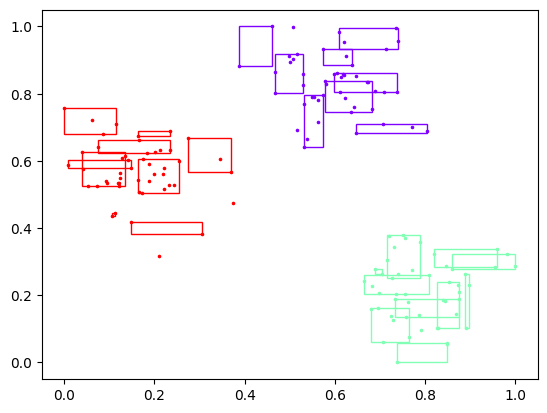

In [3]:
params = {
    "rho": 0.9,
    "alpha": 0.0,
    "beta": 1.0
}
art = FuzzyART(**params)


X = art.prepare_data(data)
print("Prepared data has shape:", X.shape)

cls = SimpleARTMAP(art)

cls = cls.fit(X, target)
y = cls.labels_

print(f"{cls.module_a.n_clusters} clusters found")

cls.visualize(X, y)

plt.show()

